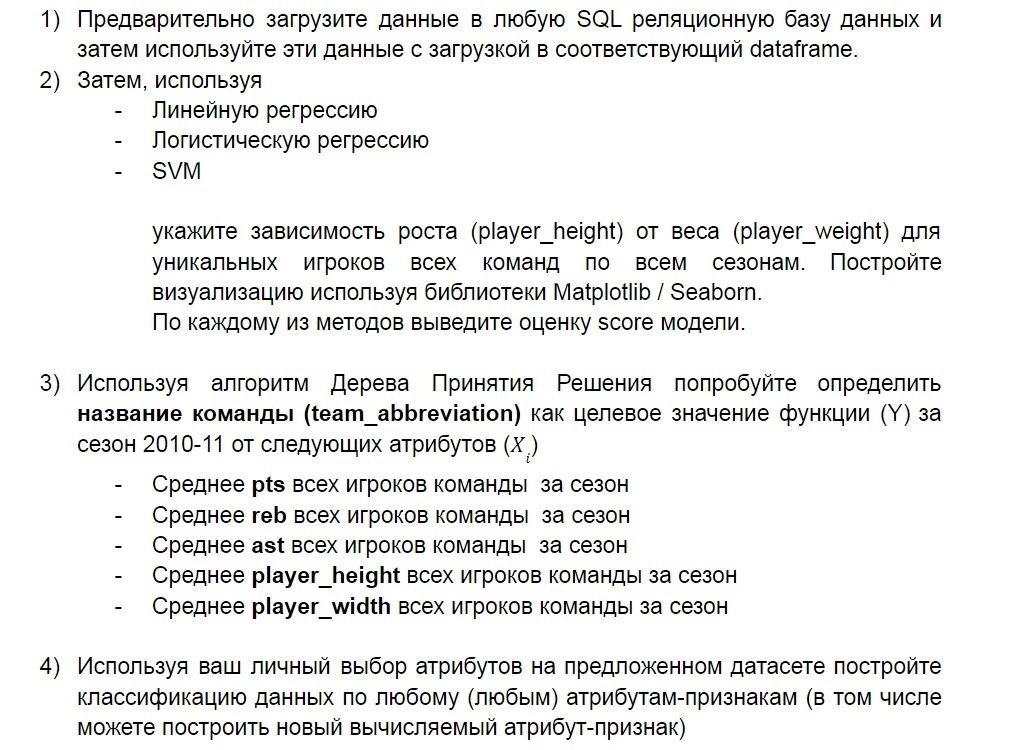

In [1]:
import pandas as pd
import numpy as np

## загрузка таблицы

In [2]:
from sqlite3 import connect

df = pd.read_sql('SELECT * FROM dataset', connect('data/dataset.sqlite') ).convert_dtypes()
display( len(df) )
df.sample(3)

12305

,id,player_name,team_abbreviation,age,player_height,player_weight,college,country,draft_year,draft_round,...,pts,reb,ast,net_rating,oreb_pct,dreb_pct,usg_pct,ts_pct,ast_pct,season
9651,9651,Bruno Caboclo,SAC,22,205.74,92.98636,None,Brazil,2014,1.0,...,2.2,1.8,0.3,2.4,0.062,0.146,0.152,0.386,0.056,2017-18
7248,7248,Tim Duncan,SAS,37,210.82,115.66596,Wake Forest,US Virgin Islands,1997,1.0,...,17.8,9.9,2.7,10.5,0.075,0.287,0.279,0.554,0.151,2012-13
12177,12177,Larry Nance Jr.,NOP,29,200.66,111.13004,Wyoming,USA,2015,1.0,...,7.0,5.4,1.8,-1.9,0.069,0.173,0.128,0.59,0.115,2021-22


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12305 entries, 0 to 12304
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 12305 non-null  Int64  
 1   player_name        12305 non-null  string 
 2   team_abbreviation  12305 non-null  string 
 3   age                12305 non-null  Int64  
 4   player_height      12305 non-null  Float64
 5   player_weight      12305 non-null  Float64
 6   college            12305 non-null  string 
 7   country            12305 non-null  string 
 8   draft_year         12305 non-null  object 
 9   draft_round        12305 non-null  object 
 10  draft_number       12305 non-null  object 
 11  gp                 12305 non-null  Int64  
 12  pts                12305 non-null  Float64
 13  reb                12305 non-null  Float64
 14  ast                12305 non-null  Float64
 15  net_rating         12305 non-null  Float64
 16  oreb_pct           123

In [4]:
df.isnull().any()

id                   False
player_name          False
team_abbreviation    False
age                  False
player_height        False
player_weight        False
college              False
country              False
draft_year           False
draft_round          False
draft_number         False
gp                   False
pts                  False
reb                  False
ast                  False
net_rating           False
oreb_pct             False
dreb_pct             False
usg_pct              False
ts_pct               False
ast_pct              False
season               False
dtype: bool

In [5]:
# df = pd.read_csv('dataset.csv').rename(columns={'Unnamed: 0':'Id'})
# df.sample(3)

## задача регрессии

In [6]:
display( len(df) )
df_ = df[['player_name','season','player_weight','player_height']].drop_duplicates(['player_name','season',])
display( len(df_) )

12305

12301

In [7]:
df_[['player_weight','player_height',]].corr()

,player_weight,player_height
player_weight,1.000000,0.825444
player_height,0.825444,1.000000


### линейная регрессия

In [8]:
x = df_.drop_duplicates()['player_weight'].values.reshape([-1,1])
y = df_['player_height'].values.reshape([-1,1])

In [9]:
x.shape, y.shape

((12301, 1), (12301, 1))

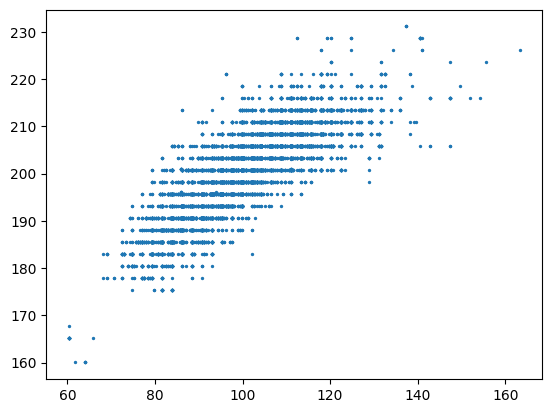

In [10]:
from matplotlib import pyplot as plt

plt.scatter(x,y,s=2)

In [11]:
from sklearn.preprocessing import PolynomialFeatures

pln = PolynomialFeatures(degree=1,).fit(x)
x_ = pln.transform(x)

In [12]:
from sklearn.linear_model import LinearRegression

model = LinearRegression().fit(x_,y)
o = model.predict(x_)

$$y = a\cdot x + b$$

In [13]:
from sklearn.metrics import mean_squared_error

mean_squared_error(y_true=y,y_pred=o)

26.66228363864248

In [14]:
x_test = np.linspace(x.min(),x.max(),100,).reshape(-1,1)
x_test_ = pln.transform(x_test)

In [15]:
r = model.predict(x_test_)

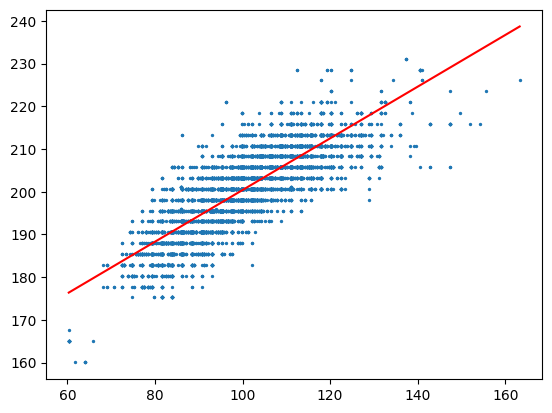

In [16]:
plt.scatter(x,y,s=2)
plt.plot(x_test,r,c='r')

### log-регрессия

#### категоризация значений

In [ ]:
# df[['player_height']].describe([.01,.1,.25,.50,.75,.95]).T
# df_[['player_height']].describe().T[['25%','50%','75%']]

In [ ]:
# labels=['low', 'mid', 'high', 'excluded']
# bins=[0, 193, 200, 208, 1000]

# df_['player_height_cut'] = pd.cut(
#         df['player_height'], 
#         bins=bins,
#         include_lowest=True, 
#         labels=labels,
#     )

In [ ]:
# def categorization(d,n_perc=5):
#     perc = np.linspace(0.,1.,n_perc)
#     bins = [ d.min()-1 ]+( d.describe(perc).iloc[4:].unique().tolist() )+[ d.max()+1 ]
#     return pd.cut( d, bins=bins, include_lowest=True, labels=range(len(bins)-1) ).astype(int)


# def binarization(d):
#     return np.eye(d.max()+1,dtype=np.float32)[np.array(d,dtype=np.uint16)] 

In [107]:
# perc = np.linspace(0,1,10)

perc = [.25,.5,.75]

bins = [0.]+(
        df_['player_height']
        .describe(perc)
        .iloc[4:]
        .unique()
        .tolist()
    )+[1000.]

display(bins)

df_['player_height_cut'] = pd.cut(
        df['player_height'], 
        bins=bins,
        include_lowest=True, 
    ).astype(str)

[0.0, 193.04, 200.66, 208.28, 231.14, 1000.0]

In [108]:
# df_['player_height_cut'] = pd.cut(
#         df['player_height'], 
#         bins=bins,
#         include_lowest=True, 
#         labels=labels,
#     )

In [109]:
df_[['player_weight','player_height_cut']]

,player_weight,player_height_cut
0,99.79024,"(193.04, 200.66]"
1,117.93392,"(208.28, 231.14]"
2,95.25432,"(200.66, 208.28]"
3,100.697424,"(200.66, 208.28]"
4,108.86208,"(200.66, 208.28]"
...,...,...
12300,111.13004,"(200.66, 208.28]"
12301,94.800728,"(-0.001, 193.04]"
12302,99.79024,"(-0.001, 193.04]"
12303,92.98636,"(193.04, 200.66]"


In [110]:
df_[['player_height_cut']].groupby('player_height_cut')['player_height_cut'].count()

player_height_cut
(-0.001, 193.04]    3115
(193.04, 200.66]    3206
(200.66, 208.28]    3875
(208.28, 231.14]    2105
Name: player_height_cut, dtype: int64

In [111]:
labels = sorted(set(df_['player_height_cut']))
labels_ = { l:i for i,l in enumerate(labels) }
df_['player_height_cut_N'] = df_['player_height_cut'].map( { l:i for i,l in enumerate(labels) }  ).astype(int)

In [112]:
df_[['player_weight','player_height_cut','player_height_cut_N']]

,player_weight,player_height_cut,player_height_cut_N
0,99.79024,"(193.04, 200.66]",1
1,117.93392,"(208.28, 231.14]",3
2,95.25432,"(200.66, 208.28]",2
3,100.697424,"(200.66, 208.28]",2
4,108.86208,"(200.66, 208.28]",2
...,...,...,...
12300,111.13004,"(200.66, 208.28]",2
12301,94.800728,"(-0.001, 193.04]",0
12302,99.79024,"(-0.001, 193.04]",0
12303,92.98636,"(193.04, 200.66]",1


In [113]:
x = df_['player_weight'].values.reshape([-1,1])
y = df_['player_height_cut_N'].values # .reshape([-1,1])

display( x.shape,y.shape )

(12301, 1)

(12301,)

In [114]:
# from sklearn.model_selection import train_test_split

In [115]:
from sklearn.preprocessing import PolynomialFeatures

pln = PolynomialFeatures(degree=1,).fit(x)
x_ = pln.transform(x)

$$ y = \frac{1} {1 + \exp( a \cdot x + b)}$$

In [116]:
# LogisticRegression?
# solver : {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'},

              precision    recall  f1-score   support

           0       0.75      0.78      0.76      3115
           1       0.51      0.50      0.50      3206
           2       0.54      0.65      0.59      3875
           3       0.61      0.34      0.44      2105

    accuracy                           0.59     12301
   macro avg       0.60      0.57      0.57     12301
weighted avg       0.60      0.59      0.59     12301



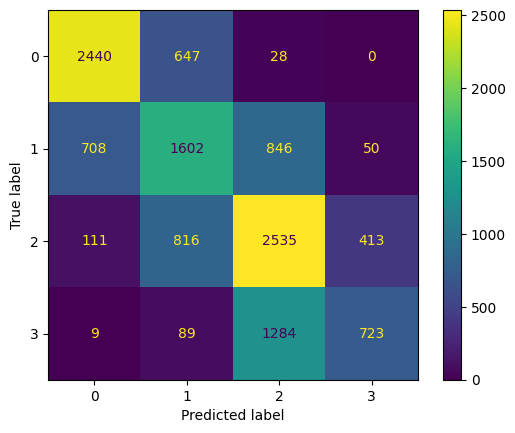

In [117]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(solver='newton-cg').fit(x_,y.flatten())

from sklearn.metrics import classification_report # метрики качества
p = model.predict(x_)
print( classification_report(y_true=y,y_pred=p) )


from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y, p), 
    #display_labels=classes
).plot()

In [118]:
df_['player_height_cut_N_pred'] = p

In [119]:
df_['player_height_cut_pred'] = df_['player_height_cut_N_pred'].map({ i:l for i,l in enumerate(labels) } )

In [120]:
# df[['player_weight','player_height_cut','player_height_cut_N']]
df_[['player_weight','player_height_cut','player_height_cut_pred']]

,player_weight,player_height_cut,player_height_cut_pred
0,99.79024,"(193.04, 200.66]","(193.04, 200.66]"
1,117.93392,"(208.28, 231.14]","(208.28, 231.14]"
2,95.25432,"(200.66, 208.28]","(193.04, 200.66]"
3,100.697424,"(200.66, 208.28]","(200.66, 208.28]"
4,108.86208,"(200.66, 208.28]","(200.66, 208.28]"
...,...,...,...
12300,111.13004,"(200.66, 208.28]","(200.66, 208.28]"
12301,94.800728,"(-0.001, 193.04]","(193.04, 200.66]"
12302,99.79024,"(-0.001, 193.04]","(193.04, 200.66]"
12303,92.98636,"(193.04, 200.66]","(193.04, 200.66]"


### SVM

              precision    recall  f1-score   support

           0       0.75      0.78      0.76      3115
           1       0.51      0.51      0.51      3206
           2       0.56      0.62      0.59      3875
           3       0.59      0.42      0.49      2105

    accuracy                           0.60     12301
   macro avg       0.60      0.58      0.59     12301
weighted avg       0.60      0.60      0.60     12301

CPU times: user 6.32 s, sys: 132 ms, total: 6.45 s
Wall time: 6.47 s


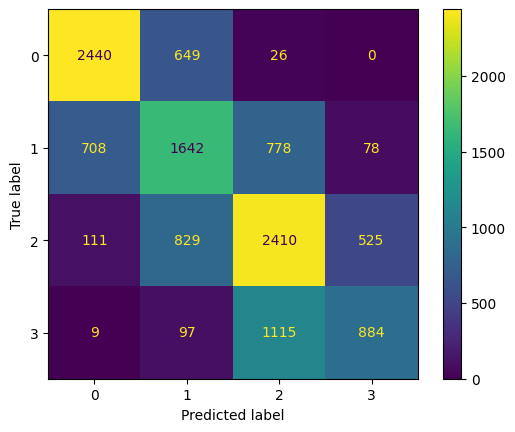

In [126]:
%%time

from sklearn.svm import SVC

# model= SVC(kernel='poly',degree=3).fit(x,y)
model= SVC().fit(x,y)

p = model.predict(x)

from sklearn.metrics import classification_report # метрики качества
print( classification_report(y_true=y,y_pred=p) )


from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay( confusion_matrix=confusion_matrix(y, p), ).plot()

## задача классификации

In [127]:
features_cols = [ 'player_height', 'player_weight', 'pts', 'reb', 'ast',]
df_ = df[ df['season']=='2010-11' ][ features_cols+ ['team_abbreviation'] ]
df_ = df_.groupby('team_abbreviation').mean().reset_index()

df_ 

,team_abbreviation,player_height,player_weight,pts,reb,ast
0,ATL,203.2,105.298143,7.892857,3.435714,1.828571
1,BOS,200.9775,103.674121,8.4375,3.525,2.0
2,CHA,201.6125,102.001501,6.66875,3.175,1.5125
3,CHI,200.66,99.20705,8.3,3.928571,1.828571
4,CLE,200.9775,102.426744,8.50625,3.875,1.7875
5,DAL,200.998667,98.852817,9.093333,3.58,2.0
6,DEN,202.837143,105.265743,9.75,4.092857,2.057143
7,DET,202.223077,100.41829,8.976923,3.592308,1.953846
8,GSW,200.345714,98.212745,8.692857,3.657143,1.95
9,HOU,203.369333,104.386639,8.413333,3.666667,1.8


In [128]:
labels = sorted(set(df_['team_abbreviation']))

In [129]:
df_['team_abbreviation_N'] = df_['team_abbreviation'].map({ l:i for i,l in enumerate(labels) } )

In [130]:
df_[features_cols + ['team_abbreviation_N']]

,player_height,player_weight,pts,reb,ast,team_abbreviation_N
0,203.2,105.298143,7.892857,3.435714,1.828571,0
1,200.9775,103.674121,8.4375,3.525,2.0,1
2,201.6125,102.001501,6.66875,3.175,1.5125,2
3,200.66,99.20705,8.3,3.928571,1.828571,3
4,200.9775,102.426744,8.50625,3.875,1.7875,4
5,200.998667,98.852817,9.093333,3.58,2.0,5
6,202.837143,105.265743,9.75,4.092857,2.057143,6
7,202.223077,100.41829,8.976923,3.592308,1.953846,7
8,200.345714,98.212745,8.692857,3.657143,1.95,8
9,203.369333,104.386639,8.413333,3.666667,1.8,9


In [131]:
x = df_[features_cols].values
target = df_['team_abbreviation_N'].values 

In [132]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier().fit(x,target)

In [133]:
p = model.predict(x)

In [134]:
from sklearn.metrics import classification_report # метрики качества

print(classification_report( y_true=target, y_pred=p, ) )

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1
           2       1.00      1.00      1.00         1
           3       1.00      1.00      1.00         1
           4       1.00      1.00      1.00         1
           5       1.00      1.00      1.00         1
           6       1.00      1.00      1.00         1
           7       1.00      1.00      1.00         1
           8       1.00      1.00      1.00         1
           9       1.00      1.00      1.00         1
          10       1.00      1.00      1.00         1
          11       1.00      1.00      1.00         1
          12       1.00      1.00      1.00         1
          13       1.00      1.00      1.00         1
          14       1.00      1.00      1.00         1
          15       1.00      1.00      1.00         1
          16       1.00      1.00      1.00         1
          17       1.00    

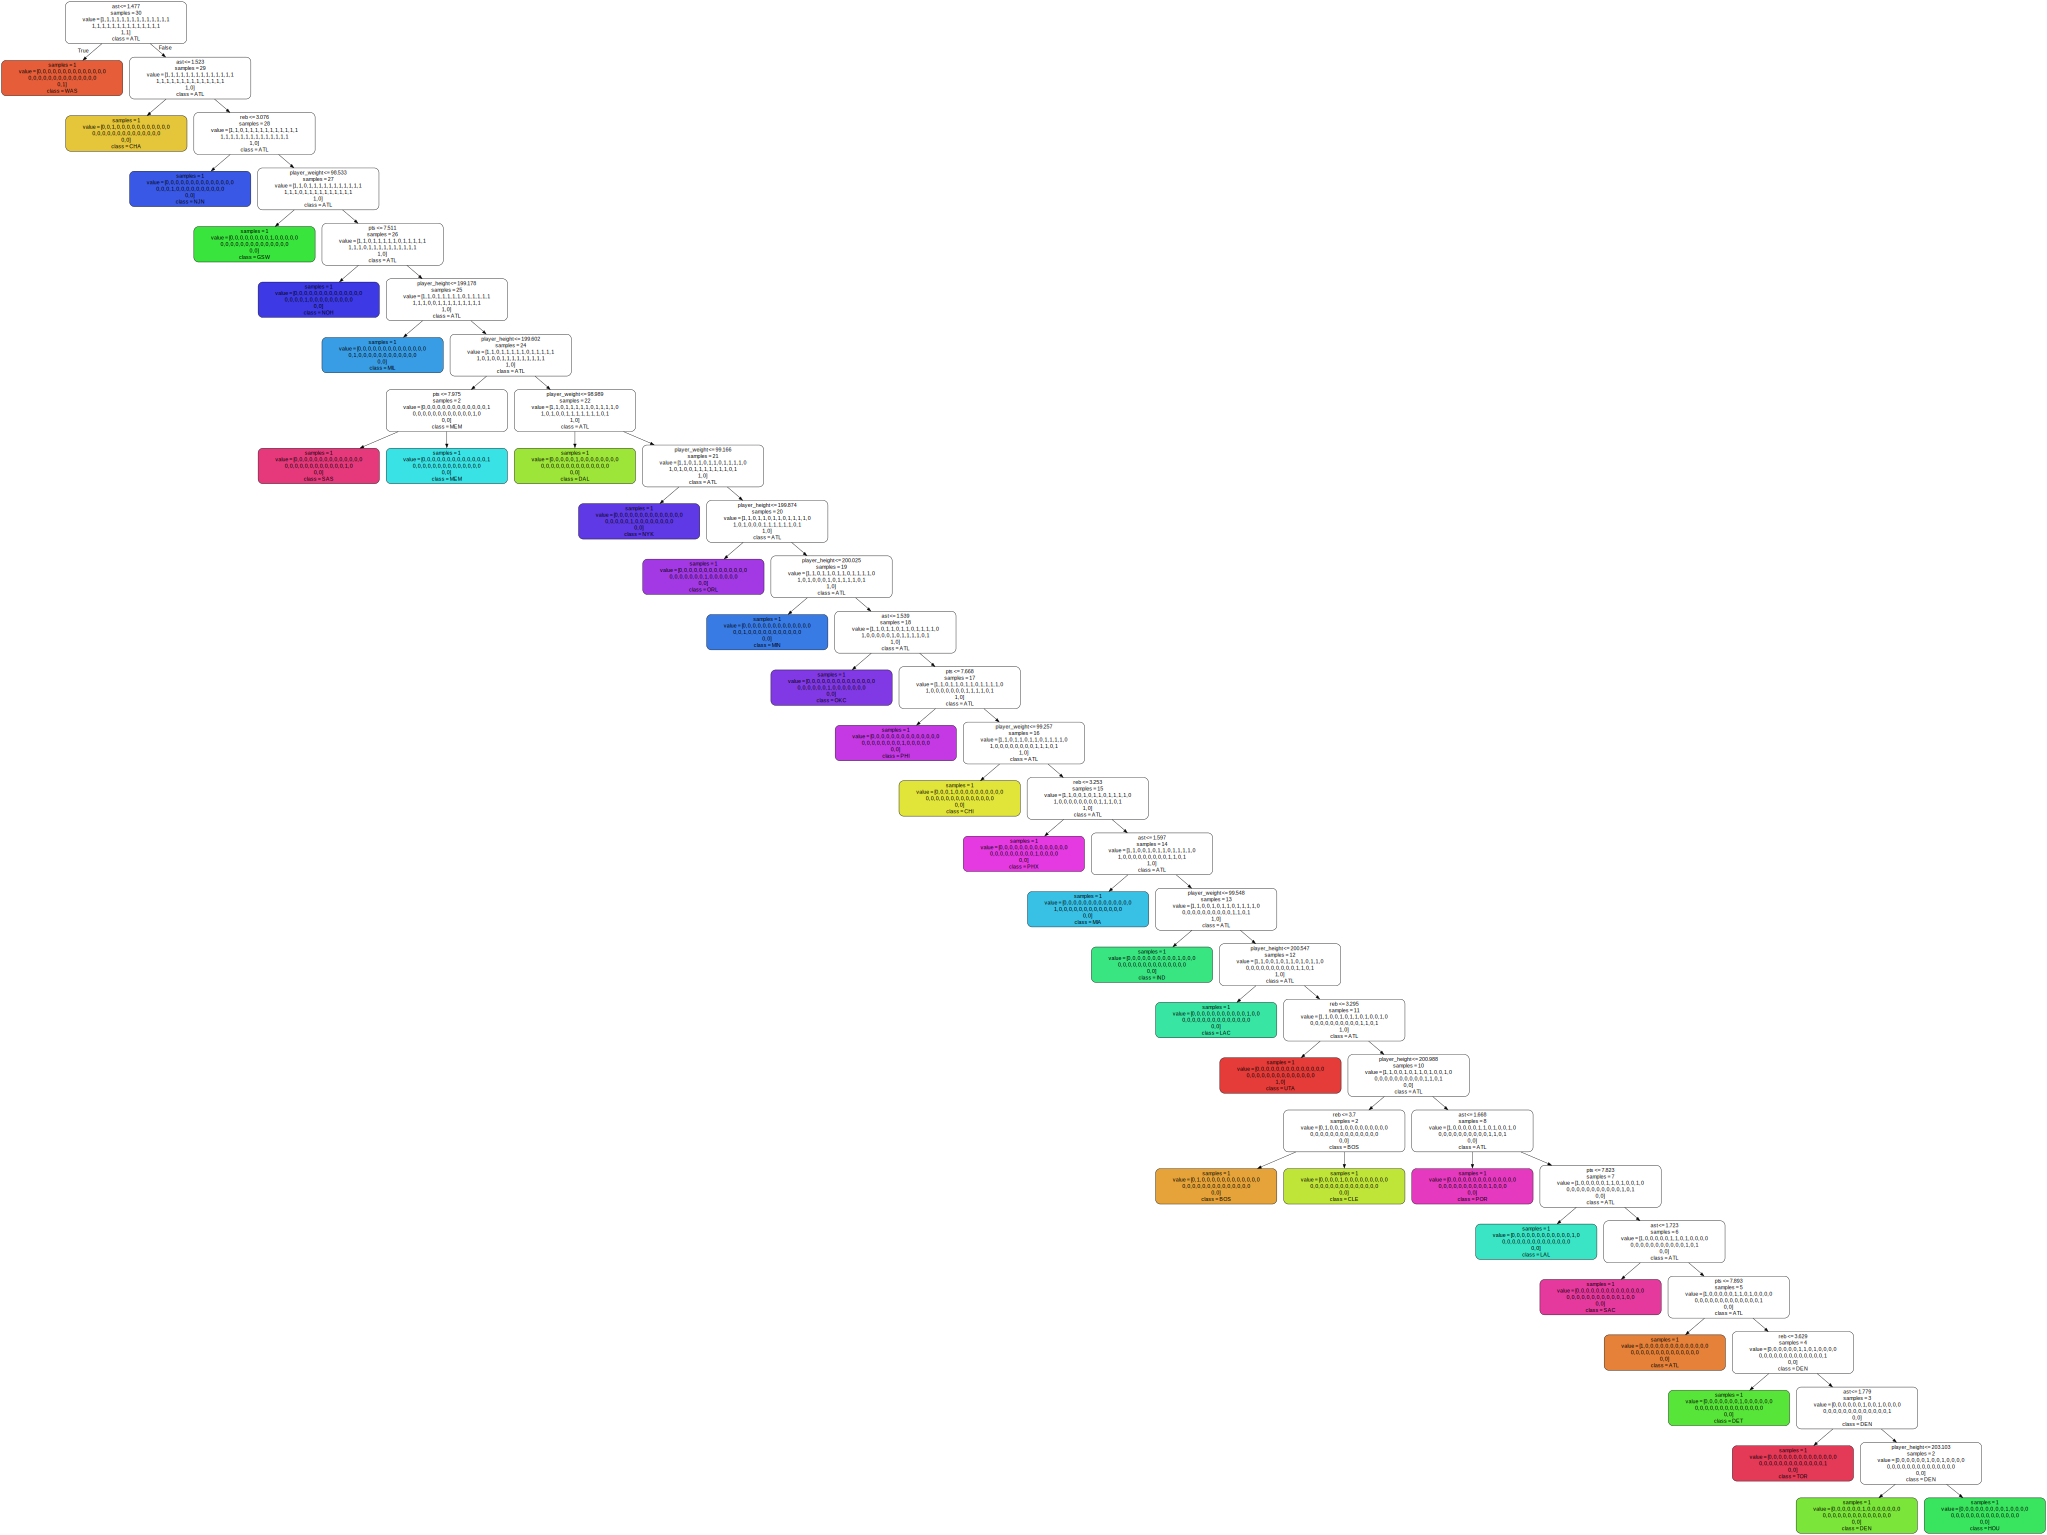

In [135]:
import graphviz
from sklearn.tree import export_graphviz

dot = graphviz.Source( 
    export_graphviz(
        model,
        feature_names=features_cols,
        class_names=labels,
        filled=True, 
        rounded=True,
        #label='root',
        impurity=False,
        #proportion=True,
    ) 
)

dot

In [ ]:
dot.render(filename='tree',format='png')

----

In [137]:
df

,id,player_name,team_abbreviation,age,player_height,player_weight,college,country,draft_year,draft_round,...,pts,reb,ast,net_rating,oreb_pct,dreb_pct,usg_pct,ts_pct,ast_pct,season
0,0,Dennis Rodman,CHI,36,198.12,99.79024,Southeastern Oklahoma State,USA,1986,2.0,...,5.7,16.1,3.1,16.1,0.186,0.323,0.1,0.479,0.113,1996-97
1,1,Dwayne Schintzius,LAC,28,215.9,117.93392,Florida,USA,1990,1.0,...,2.3,1.5,0.3,12.3,0.078,0.151,0.175,0.43,0.048,1996-97
2,2,Earl Cureton,TOR,39,205.74,95.25432,Detroit Mercy,USA,1979,3.0,...,0.8,1.0,0.4,-2.1,0.105,0.102,0.103,0.376,0.148,1996-97
3,3,Ed O'Bannon,DAL,24,203.2,100.697424,UCLA,USA,1995,1.0,...,3.7,2.3,0.6,-8.7,0.06,0.149,0.167,0.399,0.077,1996-97
4,4,Ed Pinckney,MIA,34,205.74,108.86208,Villanova,USA,1985,1.0,...,2.4,2.4,0.2,-11.2,0.109,0.179,0.127,0.611,0.04,1996-97
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12300,12300,Markieff Morris,MIA,32,205.74,111.13004,Kansas,USA,2011,1.0,...,7.6,2.6,1.4,4.5,0.059,0.089,0.197,0.547,0.116,2021-22
12301,12301,Markelle Fultz,ORL,24,193.04,94.800728,Washington,USA,2017,1.0,...,10.8,2.7,5.5,-5.3,0.01,0.116,0.265,0.517,0.448,2021-22
12302,12302,Marcus Smart,BOS,28,193.04,99.79024,Oklahoma State,USA,2014,1.0,...,12.1,3.8,5.9,9.3,0.018,0.093,0.179,0.54,0.245,2021-22
12303,12303,Marcus Garrett,MIA,23,195.58,92.98636,Kansas,USA,Undrafted,Undrafted,...,1.1,1.9,0.6,5.8,0.072,0.108,0.086,0.28,0.069,2021-22
